# Proyek Akhir: Menyelesaikan Permasalahan Institusi Pendidikan

- Nama:Kadek Indri Anisa Putri
- Email:indrianisaputri14@gmail.com
- Id Dicoding:indrianisaputri

## Persiapan

### Menyiapkan library yang dibutuhkan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

### Menyiapkan data yang akan diguankan

## Load Data

In [2]:
df = pd.read_csv('data.csv', sep=';')
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Data Understanding

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

In [4]:
df.describe()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [5]:
df.columns

Index(['Marital_status', 'Application_mode', 'Application_order', 'Course',
       'Daytime_evening_attendance', 'Previous_qualification',
       'Previous_qualification_grade', 'Nacionality', 'Mothers_qualification',
       'Fathers_qualification', 'Mothers_occupation', 'Fathers_occupation',
       'Admission_grade', 'Displaced', 'Educational_special_needs', 'Debtor',
       'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder',
       'Age_at_enrollment', 'International',
       'Curricular_units_1st_sem_credited',
       'Curricular_units_1st_sem_enrolled',
       'Curricular_units_1st_sem_evaluations',
       'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade',
       'Curricular_units_1st_sem_without_evaluations',
       'Curricular_units_2nd_sem_credited',
       'Curricular_units_2nd_sem_enrolled',
       'Curricular_units_2nd_sem_evaluations',
       'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade',
       'Curricular_units_2nd_sem_wit

In [6]:
# df['Status'].value_counts()

In [7]:
df['Status'] = df['Status'].apply(lambda x: 1 if x == 'Dropout' else 0)

## Distribusi Status

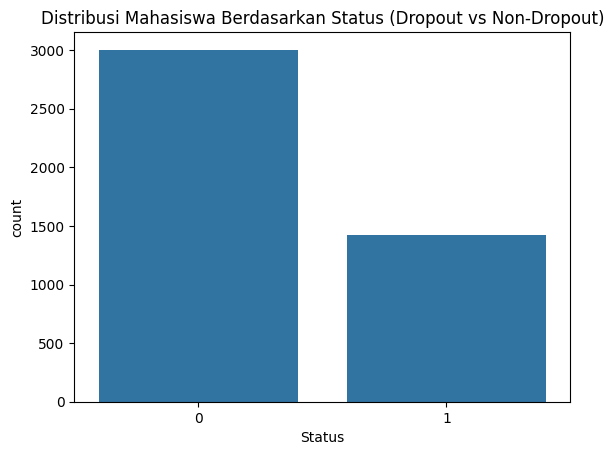

In [8]:
sns.countplot(x='Status', data=df)
plt.title('Distribusi Mahasiswa Berdasarkan Status (Dropout vs Non-Dropout)')
plt.show()

Insight:
- Proporsi mahasiswa dropout tergolong cukup tinggi dibandingkan non-dropout.
- Hal ini menunjukkan bahwa permasalahan dropout merupakan isu signifikan yang perlu ditangani secara serius oleh institusi.
- Dataset relatif seimbang sehingga model machine learning masih dapat dilatih dengan baik tanpa perlu teknik balancing yang kompleks.

## EDA

### Nilai Semester

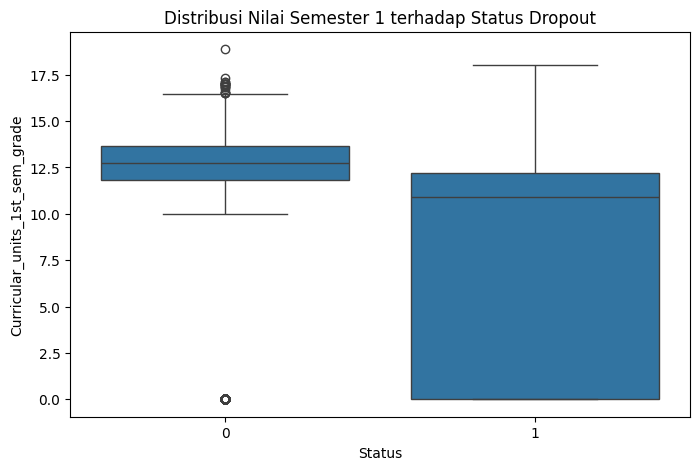

In [9]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Status', y='Curricular_units_1st_sem_grade', data=df)
plt.title('Distribusi Nilai Semester 1 terhadap Status Dropout')
plt.show()

Insight:
- Mahasiswa dengan nilai semester 1 yang rendah cenderung memiliki kemungkinan dropout yang lebih tinggi.
- Sebaliknya, mahasiswa dengan nilai tinggi lebih banyak berada pada kategori non-dropout.
- Nilai semester 1 menjadi indikator awal yang kuat untuk mendeteksi risiko dropout.

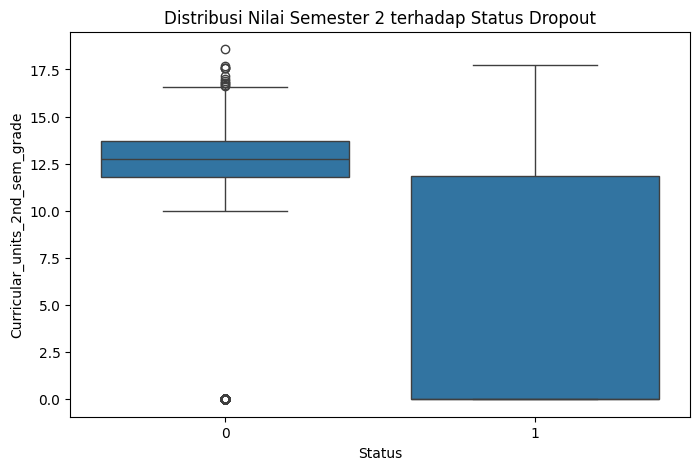

In [10]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Status', y='Curricular_units_2nd_sem_grade', data=df)
plt.title('Distribusi Nilai Semester 2 terhadap Status Dropout')    
plt.show()

Insight:
- Pola yang lebih jelas terlihat dibanding semester 1, di mana mahasiswa dengan nilai rendah hampir didominasi oleh kelompok dropout.
- Hal ini menunjukkan bahwa performa akademik yang buruk secara berkelanjutan meningkatkan risiko dropout.
- Nilai semester 2 menjadi fitur yang sangat penting dalam prediksi.

### Faktor Ekonomi

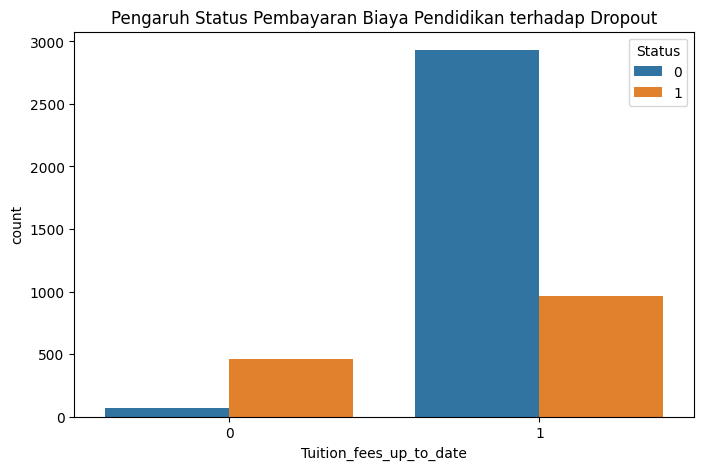

In [11]:
plt.figure(figsize=(8,5))
sns.countplot(x='Tuition_fees_up_to_date', hue='Status', data=df)
plt.title('Pengaruh Status Pembayaran Biaya Pendidikan terhadap Dropout')
plt.show()

Insight:
- Mahasiswa yang tidak membayar biaya pendidikan tepat waktu memiliki kecenderungan dropout yang lebih tinggi.
- Faktor ekonomi memiliki pengaruh signifikan terhadap keberlangsungan studi mahasiswa.
- Status pembayaran dapat menjadi indikator penting dalam sistem early warning.

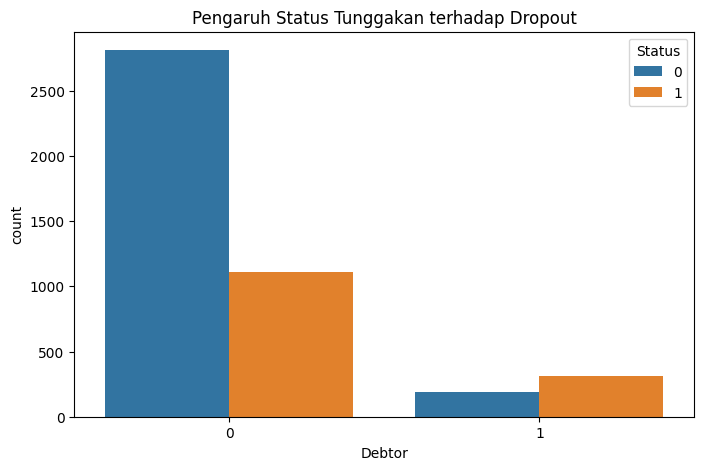

In [12]:
plt.figure(figsize=(8,5))
sns.countplot(x='Debtor', hue='Status', data=df)
plt.title('Pengaruh Status Tunggakan terhadap Dropout')
plt.show()

Insight:
- Mahasiswa dengan status debtor (memiliki tunggakan) lebih banyak berada pada kelompok dropout.
- Hal ini mengindikasikan bahwa masalah finansial berkontribusi langsung terhadap risiko dropout.
- Faktor ini relevan untuk kebijakan bantuan finansial atau restrukturisasi pembayaran.

### Demografi

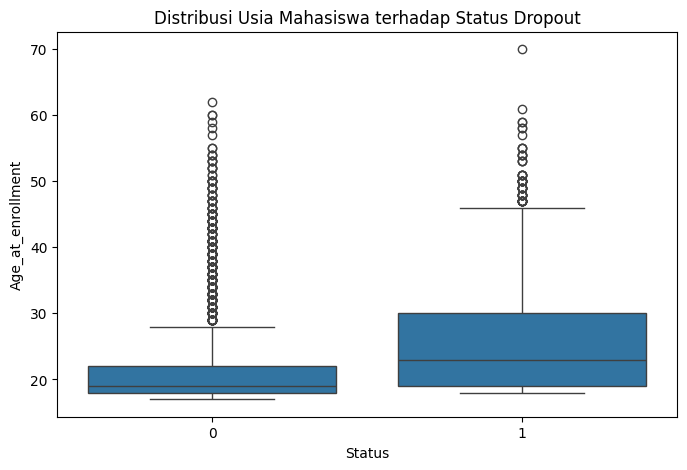

In [13]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Status', y='Age_at_enrollment', data=df)
plt.title('Distribusi Usia Mahasiswa terhadap Status Dropout')
plt.show()

Insight:
- Mahasiswa dengan usia lebih tinggi saat pendaftaran cenderung memiliki risiko dropout yang lebih besar.
- Hal ini dapat disebabkan oleh faktor eksternal seperti pekerjaan, tanggung jawab keluarga, atau keterbatasan waktu.
- Usia menjadi faktor tambahan yang dapat dipertimbangkan dalam analisis risiko.

### Mata Kuliah yang Disetujui (Semester 1)

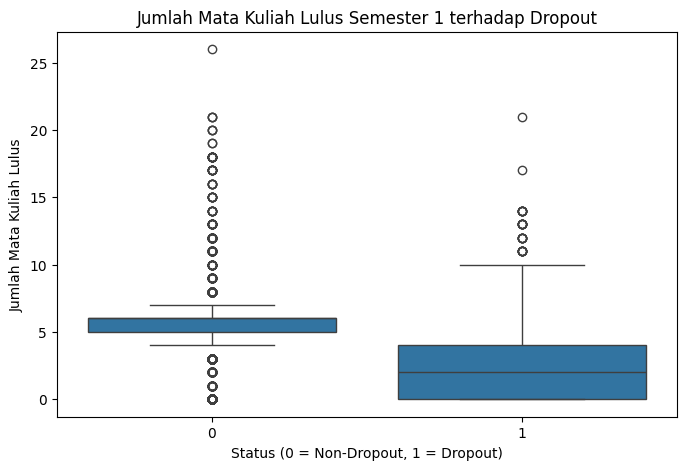

In [14]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Status', y='Curricular_units_1st_sem_approved', data=df)
plt.title('Jumlah Mata Kuliah Lulus Semester 1 terhadap Dropout')
plt.xlabel('Status (0 = Non-Dropout, 1 = Dropout)')
plt.ylabel('Jumlah Mata Kuliah Lulus')
plt.show()

Insight:
- Mahasiswa dengan jumlah mata kuliah lulus yang rendah memiliki kemungkinan dropout lebih tinggi.
- Ini menunjukkan bahwa bukan hanya nilai, tapi progress akademik juga penting.

### Beasiswa

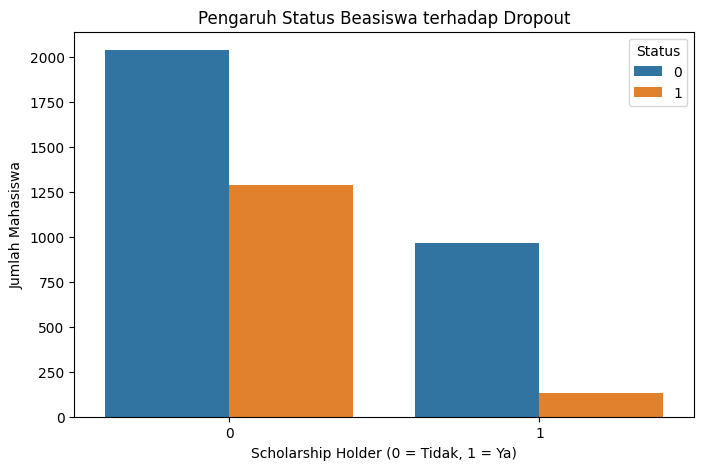

In [15]:
plt.figure(figsize=(8,5))
sns.countplot(x='Scholarship_holder', hue='Status', data=df)
plt.title('Pengaruh Status Beasiswa terhadap Dropout')
plt.xlabel('Scholarship Holder (0 = Tidak, 1 = Ya)')
plt.ylabel('Jumlah Mahasiswa')
plt.legend(title='Status')
plt.show()

Insight:
- Mahasiswa penerima beasiswa cenderung memiliki risiko dropout lebih rendah.
- Hal ini menunjukkan bahwa dukungan finansial dapat meningkatkan keberlangsungan studi.

## Data Preparation / Preprocessing

### Encode Status

In [16]:
le = LabelEncoder()
df['Status'] = le.fit_transform(df['Status'])

In [17]:
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(mapping)

{0: 0, 1: 1}


### Retrain Model

In [18]:
features = [
    'Age_at_enrollment',
    'Curricular_units_1st_sem_grade',
    'Curricular_units_2nd_sem_grade',
    'Curricular_units_1st_sem_approved',
    'Curricular_units_2nd_sem_approved',
    'Tuition_fees_up_to_date',
    'Debtor'
]

X = df[features]
y = df['Status']

### Train Test Split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Modeling

In [20]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Save Model

In [21]:
import pickle

with open('model/model.pkl', 'wb') as f:
    pickle.dump(model, f)

In [22]:
y_pred = model.predict(X_test)

## Evaluation

In [23]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8327683615819209


In [24]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.92      0.88       569
           1       0.82      0.68      0.74       316

    accuracy                           0.83       885
   macro avg       0.83      0.80      0.81       885
weighted avg       0.83      0.83      0.83       885



Model memiliki akurasi sekitar 83%, yang menunjukkan performa yang cukup baik dalam memprediksi status mahasiswa.
Model mampu mengidentifikasi sebagian besar mahasiswa non-dropout dengan baik, namun masih terdapat kesalahan dalam mendeteksi mahasiswa dropout.
Hal ini menunjukkan bahwa model masih memiliki keterbatasan dalam menangkap seluruh karakteristik mahasiswa berisiko tinggi.

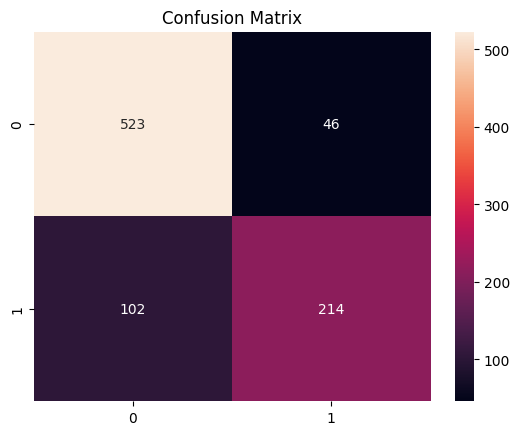

In [25]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.show()

Berdasarkan confusion matrix, model masih menghasilkan kesalahan pada prediksi mahasiswa dropout (false negative), yang berpotensi menyebabkan mahasiswa berisiko tidak terdeteksi lebih awal.

## Feature Importance

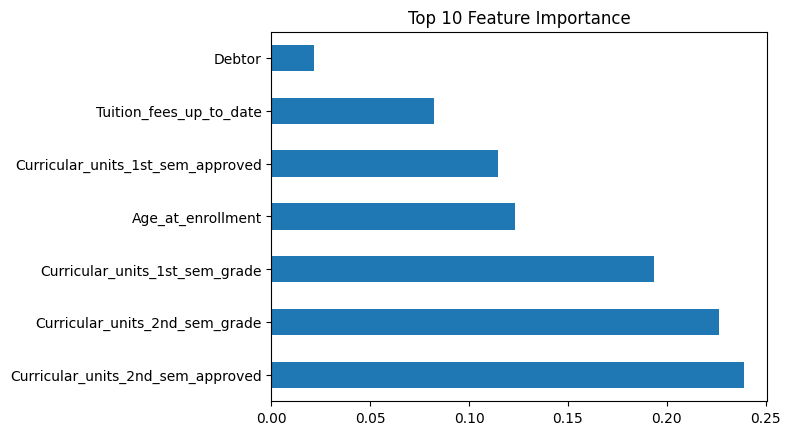

In [26]:
importances = model.feature_importances_
feat_importance = pd.Series(importances, index=X.columns)
feat_importance.nlargest(10).plot(kind='barh')
plt.title('Top 10 Feature Importance')
plt.show()

In [27]:
df.to_csv('institusi_data_clean.csv', index=False)